In [2]:
from gbm.data import TTE
from gbm.binning.unbinned import bin_by_time
import os

fitn9 = os.path.join('..', 'data', 'glg_tte_n9_bn201216963_v00.fit')
fitna = os.path.join('..', 'data', 'glg_tte_na_bn201216963_v00.fit')

tte9 = TTE.open(fitn9)
ttea = TTE.open(fitna)
phaii9 = tte9.to_phaii(bin_by_time, 1.024, time_ref=0.0)
phaiia = ttea.to_phaii(bin_by_time, 1.024, time_ref=0.0)

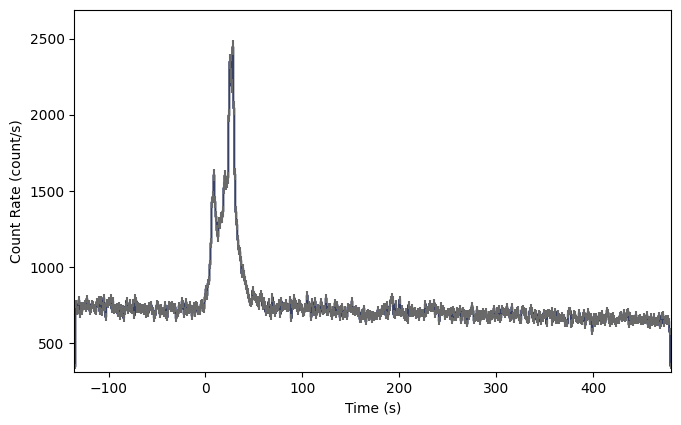

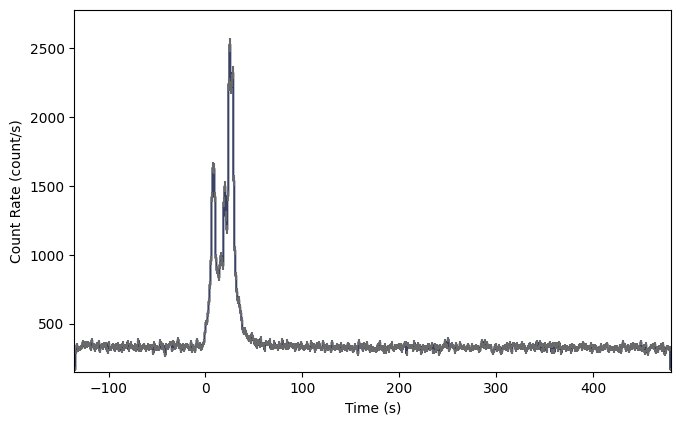

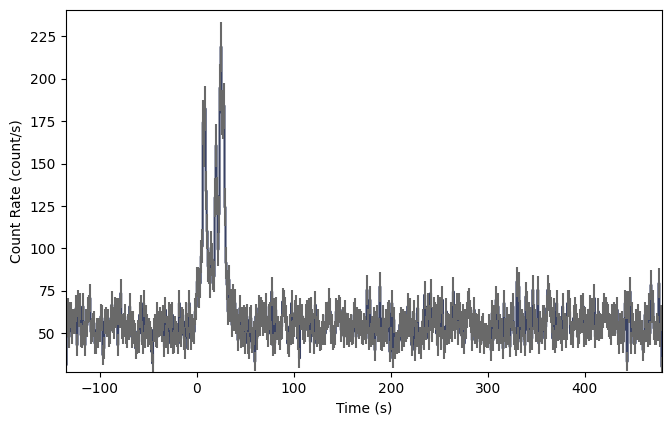

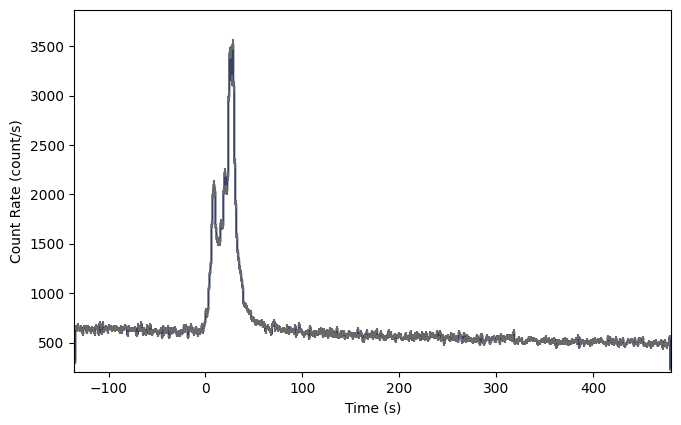

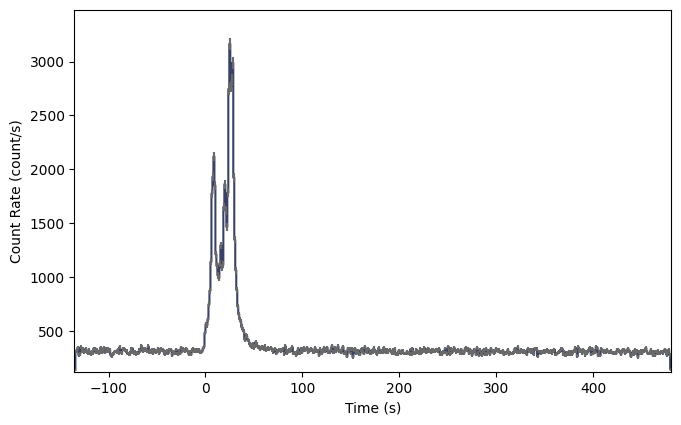

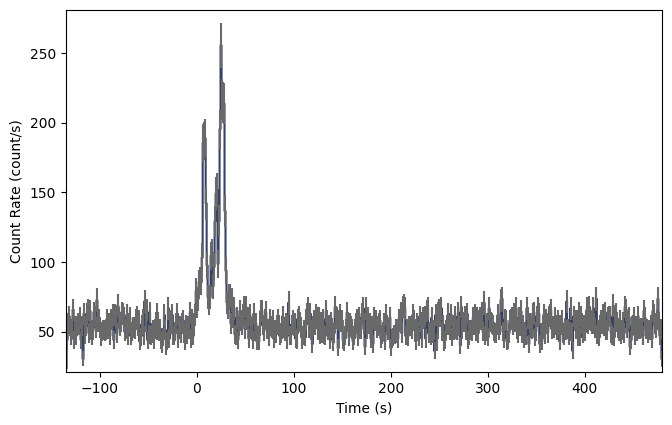

In [5]:
%matplotlib inline
from gbm.plot import Lightcurve

erange = (8.0, 900.0)
erange1 = (8.0, 50.0)
erange2 = (50.0, 300.0)
erange3 = (300.0, 900.0)

lc_data1_n9 = phaii9.to_lightcurve(energy_range=erange1)
lcplot1_n9 = Lightcurve(data=lc_data1_n9)

lc_data2_n9 = phaii9.to_lightcurve(energy_range=erange2)
lcplot2_n9 = Lightcurve(data=lc_data2_n9)

lc_data3_n9 = phaii9.to_lightcurve(energy_range=erange3)
lcplot3_n9 = Lightcurve(data=lc_data3_n9)

lc_data1_na = phaiia.to_lightcurve(energy_range=erange1)
lcplot1_na = Lightcurve(data=lc_data1_na)

lc_data2_na = phaiia.to_lightcurve(energy_range=erange2)
lcplot2_na = Lightcurve(data=lc_data2_na)

lc_data3_na = phaiia.to_lightcurve(energy_range=erange3)
lcplot3_na = Lightcurve(data=lc_data3_na)

In [23]:
import numpy as np

def get_T90(phaii):
    """
    Compute T5, T95, and T90 for a GBM light curve
    """
    times = phaii.data.time_centroids
    counts = phaii.data.counts.sum(axis=1)

    cumulative = np.cumsum(counts)
    cumulative = (cumulative - cumulative.min()) / (cumulative.max() - cumulative.min())

    T5  = np.interp(0.05, cumulative, times)
    T95 = np.interp(0.95, cumulative, times)
    T90 = T95 - T5
    return float(T5), float(T95), float(T90)

# Example:
T5, T95, T90 = get_T90(phaii9)

bkgd_range = [(T5 - 50, T5 - 10), (T95 + 10, T95 + 50)]
print(bkgd_range)

[(-152.39508751033912, -112.39508751033912), (454.11262222222217, 494.11262222222217)]


In [103]:
view_range = (-10.0, 100.0)
src_range = (25.0, 28.0)
erange_nai = (8.0, 900.0)
erange_bgo = (325., 25000.)

In [25]:
from gbm.data import Cspec, GbmDetectorCollection

test_pha_n9 = os.path.join('..', 'data', 'glg_cspec_n9_bn201216963_v00.pha')
test_pha_na = os.path.join('..', 'data', 'glg_cspec_na_bn201216963_v00.pha')
test_pha_b0 = os.path.join('..', 'data', 'glg_cspec_b0_bn201216963_v00.pha')
n9 = Cspec.open(test_pha_n9)
na = Cspec.open(test_pha_na)
b0 = Cspec.open(test_pha_b0)

cspecs = GbmDetectorCollection.from_list([n9, na, b0])

In [26]:
from gbm.background import BackgroundFitter
from gbm.background.binned import Polynomial

backfitters = [BackgroundFitter.from_phaii(cspec, Polynomial, time_ranges=bkgd_range) for cspec in cspecs]
backfitters = GbmDetectorCollection.from_list(backfitters, dets=cspecs.detector())

# do the fit
backfitters.fit(order=1)

# interpolate/extrapolate and store in a collection
bkgds = backfitters.interpolate_bins(cspecs.data()[0].tstart, cspecs.data()[0].tstop)
bkgds = GbmDetectorCollection.from_list(bkgds, dets=cspecs.detector())

In [104]:
# the lightcurves
data_lcs = cspecs.to_lightcurve(nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})
# the energy-integrated background
bkgd_lcs = bkgds.integrate_energy(nai_args=erange_nai, bgo_args=erange_bgo)
# the source time selection
src_lcs = cspecs.to_lightcurve(time_range=src_range, nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

# the count spectrum
data_specs = cspecs.to_spectrum(time_range=src_range)
# the time-integrated background
bkgd_specs = bkgds.integrate_time(*src_range)
# the energy selection
src_specs = cspecs.to_spectrum(time_range=src_range, nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

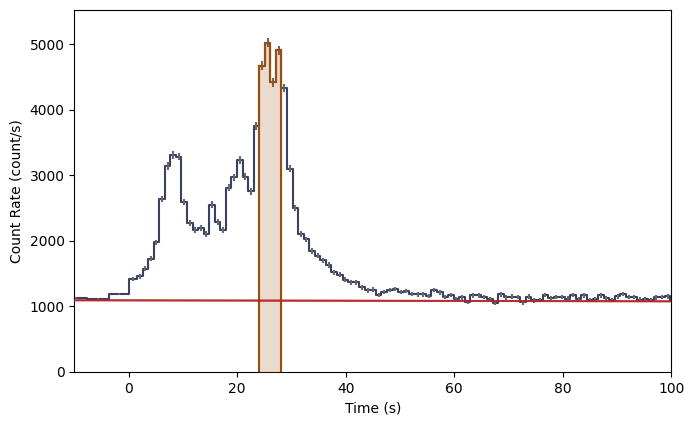

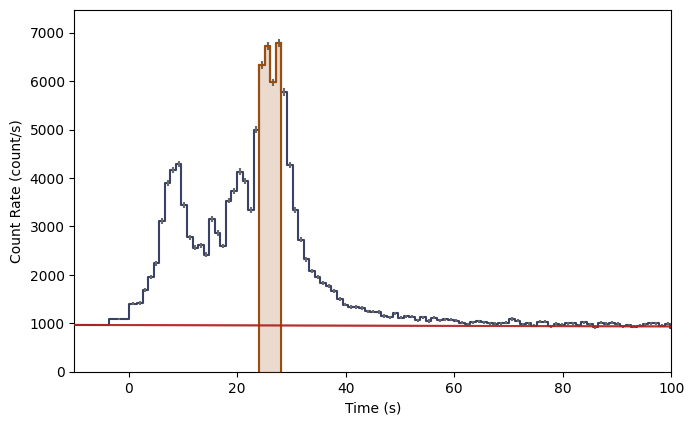

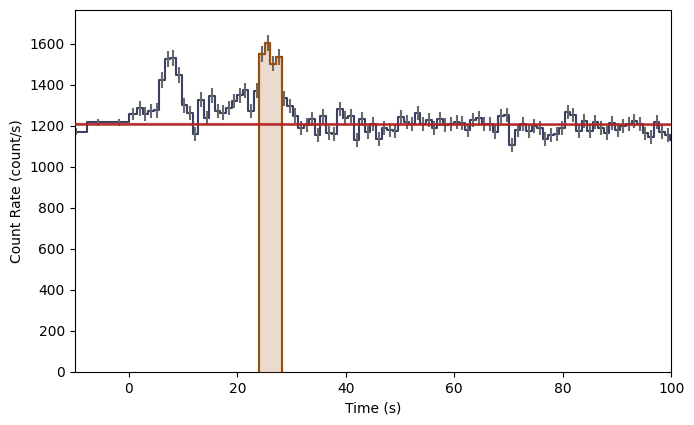

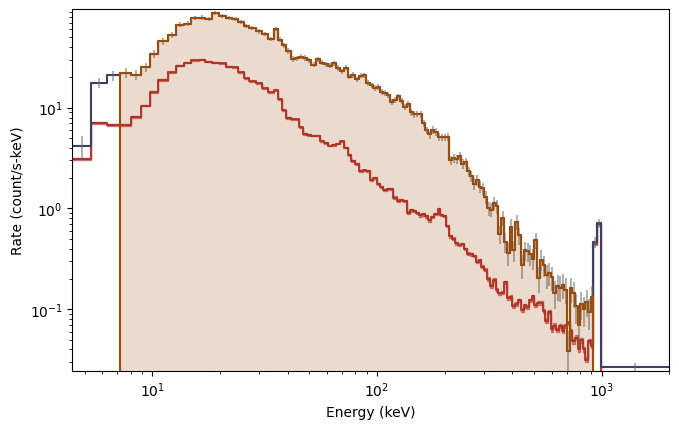

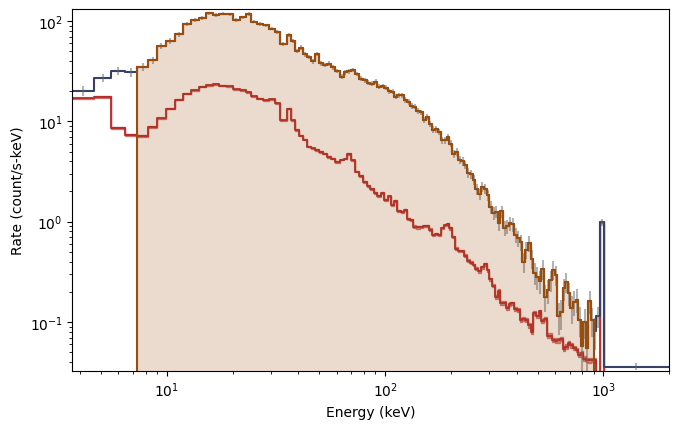

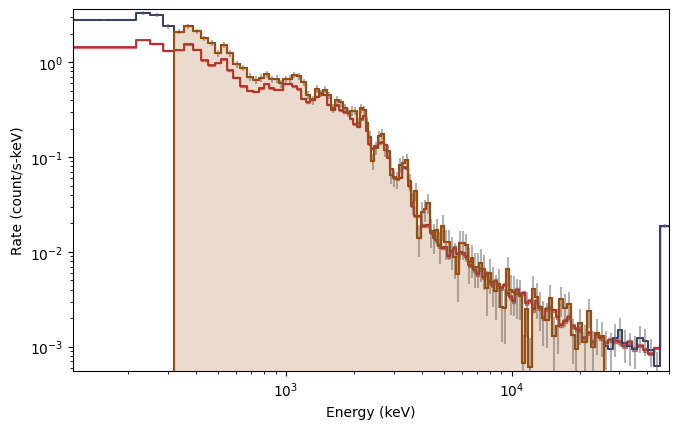

In [105]:
%matplotlib inline
from gbm.plot import Lightcurve, Spectrum

# Plot the lightcurves with the selections and background fit
lcplots = [Lightcurve(data=data_lc, background=bkgd_lc) for data_lc, bkgd_lc in zip(data_lcs, bkgd_lcs)]
_ = [lcplot.add_selection(src_lc) for lcplot, src_lc in zip(lcplots, src_lcs)]
# zoom in
for lcplot in lcplots:
    lcplot.xlim = view_range

# Plot the spectra with the selections and background fit
specplots = [Spectrum(data=data_spec, background=bkgd_spec) for data_spec, bkgd_spec in zip(data_specs, bkgd_specs)]
_ = [specplot.add_selection(src_spec) for specplot, src_spec in zip(specplots, src_specs)]

In [96]:
from gbm.spectra.fitting import SpectralFitterCstat
from gbm.data import RSP
from gbm.spectra.functions import PowerLaw, Comptonized, Band, BlackBody
import numpy as np

phas = cspecs.to_pha(time_ranges=src_range, nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

rsp_dir_n9 = os.path.join('..', 'data', 'glg_cspec_n9_bn201216963_v02.rsp2')
rsp_dir_na = os.path.join('..', 'data', 'glg_cspec_na_bn201216963_v02.rsp2')
rsp_dir_b0 = os.path.join('..', 'data', 'glg_cspec_b0_bn201216963_v02.rsp2')

# open responses
rsp1 = RSP.open(rsp_dir_n9)
rsp2 = RSP.open(rsp_dir_na)
rsp3 = RSP.open(rsp_dir_b0)
rsps = GbmDetectorCollection.from_list([rsp1, rsp2, rsp3])

# and interpolate response files to get DRMs at center of the source window
rsps_interp = [rsp.interpolate(pha.tcent) for rsp, pha in zip(rsps, phas)]

# we initialize with our PHAs, backgrounds, and responses:
specfitter = SpectralFitterCstat(phas, bkgds.to_list(), rsps_interp, method='TNC')

blackbody = BlackBody()
specfitter.fit(blackbody, options={'maxiter': 1000})
print("BlackBody Fit:")
print(specfitter.message)
print('Parameters: {}'.format(specfitter.parameters))
print('90% Asymm. Errors:\n {}'.format(specfitter.asymmetric_errors(cl=0.9)))
print('Cstat/DoF: {}/{}'.format(specfitter.statistic, specfitter.dof))

bb_params = specfitter.parameters.copy()
bb_cov = specfitter.covariance.copy()

BlackBody Fit:
Max. number of function evaluations reached
Parameters: [2.78996542e-04 2.57562314e+01]
90% Asymm. Errors:
 [[8.94272240e-06 9.28043448e-06]
 [2.84780790e-01 2.07647895e-01]]
Cstat/DoF: 714.0591707337171/352


In [43]:
band = Band()
band.param_list

print('Band:')
print(band.default_values)
print(band.min_values)
print(band.max_values)

print('Band Fit:')
specfitter.fit(band, options={'maxiter': 1000})

# Extract the Band parameters from the fit
params_band = specfitter.parameters

# After the fit has converged, we can query the fitter for lots of info, including the parameters that
# satisfy the maximum likelihood as well as the parameter uncertainties resulting from -2(Delta)LogLike
print(specfitter.message)
print('Parameters: {}'.format(specfitter.parameters))
print('90% Asymm. Errors:\n {}'.format(specfitter.asymmetric_errors(cl=0.9)))
print('Cstat/DoF: {}/{}'.format(specfitter.statistic, specfitter.dof))

Band:
[0.01, 500.0, -0.5, -2.5, 100.0]
[1e-10, 0.01, -1.9, -10.0, 0.01]
[inf, inf, 20.0, -2.0001, inf]
Band Fit:
Converged (|f_n-f_(n-1)| ~= 0)
Parameters: [ 6.33109263e-02  2.50680324e+02 -9.95647167e-01 -7.65944673e+00]
90% Asymm. Errors:
 [[2.31670232e-03 2.33009605e-03]
 [1.79287560e+01 1.93827730e+01]
 [3.58229419e-02 3.75121288e-02]
 [2.34055327e+00 5.29652311e+00]]
Cstat/DoF: 138.2619137804723/350


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

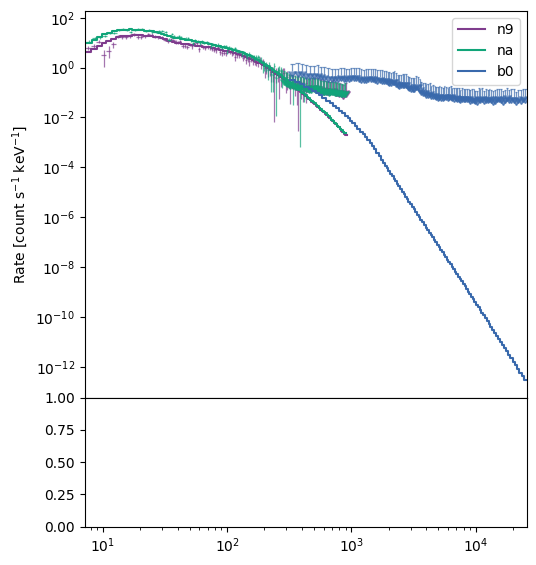

In [44]:
from gbm.plot import ModelFit
import numpy as np

if not hasattr(np, 'VisibleDeprecationWarning'):
    # Mapear a DeprecationWarning para compatibilidad con paquetes que lo esperan
    np.VisibleDeprecationWarning = DeprecationWarning

# initialize with your spectral fitter once the fit is done
modelplot = ModelFit(fitter=specfitter)

/home/reegh/Documentos/Astro/Astro-GRBs/gbm/lib/python3.10/site-packages/gbm/spectra/fitting.py:600: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = multivariate_normal(self.parameters, self.covariance,


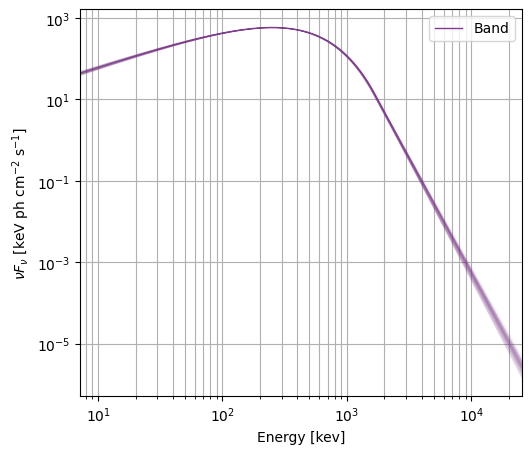

In [45]:
import matplotlib.legend as mlegend

if not hasattr(mlegend.Legend, 'legendHandles'):
    def _get_legendHandles(self):
        # devolver el atributo nuevo si existe, sino intentar variantes, sino lista vacía
        return getattr(self, 'legend_handles', getattr(self, '_legend_handles', []))
    mlegend.Legend.legendHandles = property(_get_legendHandles)

modelplot = ModelFit(fitter=specfitter, view='nufnu')
modelplot.ax.grid(which='both')

/home/reegh/Documentos/Astro/Astro-GRBs/gbm/lib/python3.10/site-packages/gbm/spectra/fitting.py:600: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = multivariate_normal(self.parameters, self.covariance,


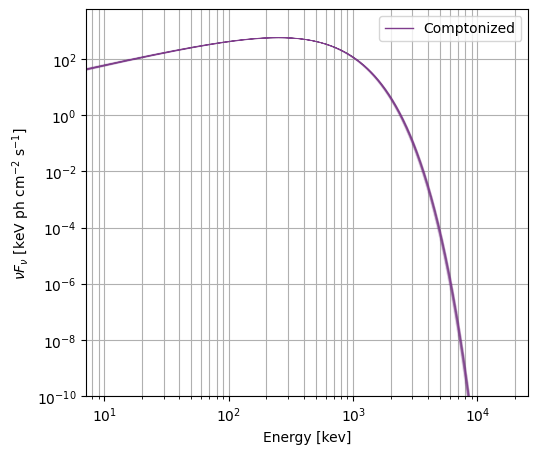

In [ ]:
specfitter.fit(Comptonized(), options= {'maxiter': 1000})

if not hasattr(mlegend.Legend, 'legendHandles'):
    def _get_legendHandles(self):
        # devolver el atributo nuevo si existe, sino intentar variantes, sino lista vacía
        return getattr(self, 'legend_handles', getattr(self, '_legend_handles', []))
    mlegend.Legend.legendHandles = property(_get_legendHandles)

modelplot = ModelFit(fitter=specfitter, view='nufnu')
modelplot.ax.grid(which='both')

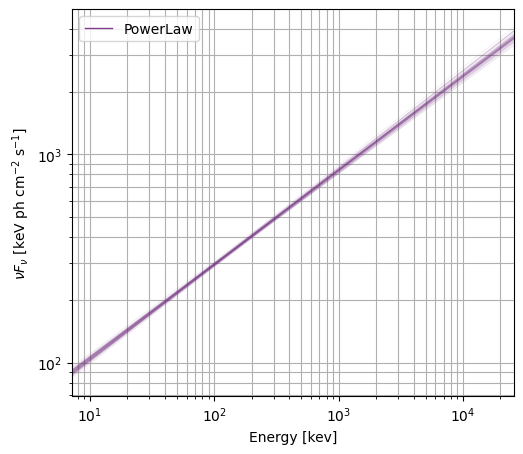

In [ ]:
specfitter.fit(PowerLaw(), options= {'maxiter': 1000})

if not hasattr(mlegend.Legend, 'legendHandles'):
    def _get_legendHandles(self):
        # devolver el atributo nuevo si existe, sino intentar variantes, sino lista vacía
        return getattr(self, 'legend_handles', getattr(self, '_legend_handles', []))
    mlegend.Legend.legendHandles = property(_get_legendHandles)

modelplot = ModelFit(fitter=specfitter, view='nufnu')
modelplot.ax.grid(which='both')

In [122]:
# we've defined a new model that is the sum of a Comptonized function and a power law
comp_pl = Comptonized() + PowerLaw()

# rerun the fit
print('Comp+PL Fit:')
specfitter.fit(comp_pl, options= {'maxiter': 1000})

print(specfitter.message)
print('Parameters: {}'.format(specfitter.parameters))
print('90% Asymm. Errors:\n {}'.format(specfitter.asymmetric_errors(cl=0.9)))
print('Cstat/DoF: {}/{}'.format(specfitter.statistic, specfitter.dof))

Comp+PL Fit:
Linear search failed
Parameters: [ 6.33071599e-02  2.50702300e+02 -9.95680275e-01  1.00000000e-10
 -1.53712375e+00]
90% Asymm. Errors:
 [[2.52345374e-03 2.53955479e-03]
 [1.94733108e+01 2.11987632e+01]
 [3.89452678e-02 4.09765462e-02]
 [1.10168451e-03 1.10168452e-03]
 [1.53712375e+00 2.75894255e+00]]
Cstat/DoF: 138.26208916243044/349


/home/reegh/Documentos/Astro/Astro-GRBs/gbm/lib/python3.10/site-packages/gbm/spectra/fitting.py:600: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = multivariate_normal(self.parameters, self.covariance,
/home/reegh/Documentos/Astro/Astro-GRBs/gbm/lib/python3.10/site-packages/gbm/spectra/functions.py:436: RuntimeWarning: overflow encountered in power
  return params[0] * (x / params[2]) ** params[1]
/home/reegh/Documentos/Astro/Astro-GRBs/gbm/lib/python3.10/site-packages/gbm/spectra/fitting.py:643: RuntimeWarning: overflow encountered in multiply
  model *= grid[np.newaxis, :] ** 2
/home/reegh/Documentos/Astro/Astro-GRBs/gbm/lib/python3.10/site-packages/matplotlib/axes/_base.py:3067: RuntimeWarning: overflow encountered in scalar subtract
  delta = (x1t - x0t) * margin
/home/reegh/Documentos/Astro/Astro-GRBs/gbm/lib/python3.10/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


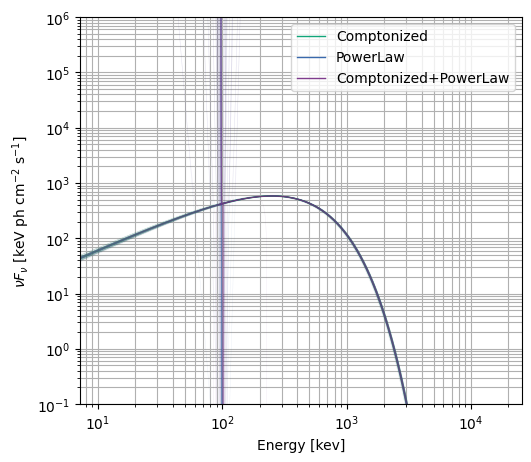

In [124]:
modelplot = ModelFit(fitter=specfitter, view='nufnu')
modelplot.ylim = (0.1, 1000000.0)
modelplot.ax.grid(which='both')

In [137]:
pl_bb = PowerLaw() + BlackBody()

# rerun the fit
print('PL+BB Fit:')
specfitter.fit(pl_bb, options= {'maxiter': 1000})

print(specfitter.message)
print('Parameters: {}'.format(specfitter.parameters))
print('90% Asymm. Errors:\n {}'.format(specfitter.asymmetric_errors(cl=0.9)))
print('Cstat/DoF: {}/{}'.format(specfitter.statistic, specfitter.dof))

PL+BB Fit:
Max. number of function evaluations reached
Parameters: [ 1.84387689e-02 -1.64963141e+00  4.44082915e-05  3.54479976e+01]
90% Asymm. Errors:
 [[1.04588274e-03 1.05255103e-03]
 [3.70985512e-02 3.77741607e-02]
 [3.91448979e-06 3.91448941e-06]
 [9.40232265e-01 9.00448607e-01]]
Cstat/DoF: 203.70746888887646/350


/home/reegh/Documentos/Astro/Astro-GRBs/gbm/lib/python3.10/site-packages/gbm/spectra/functions.py:903: RuntimeWarning: overflow encountered in exp
  fxn = A * x ** 2 / (np.exp(x / kT) - 1.0)
/home/reegh/Documentos/Astro/Astro-GRBs/gbm/lib/python3.10/site-packages/gbm/spectra/fitting.py:600: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = multivariate_normal(self.parameters, self.covariance,


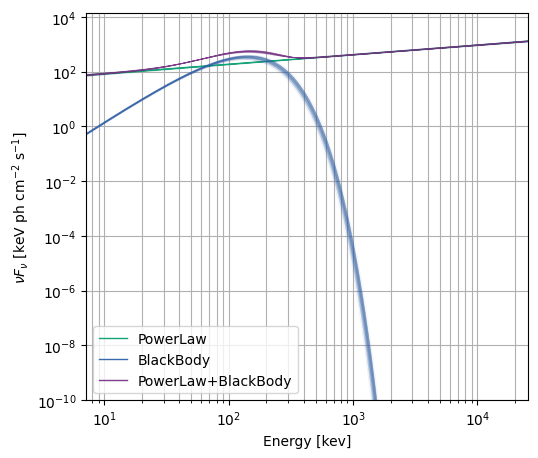

In [135]:
if not hasattr(mlegend.Legend, 'legendHandles'):
    def _get_legendHandles(self):
        # devolver el atributo nuevo si existe, sino intentar variantes, sino lista vacía
        return getattr(self, 'legend_handles', getattr(self, '_legend_handles', []))
    mlegend.Legend.legendHandles = property(_get_legendHandles)

modelplot = ModelFit(fitter=specfitter, view='nufnu')
modelplot.ax.grid(which='both')

In [139]:
comp_pl_bb = Comptonized() + PowerLaw() + BlackBody()

# rerun the fit
print('Comp+PL+BB Fit:')
specfitter.fit(comp_pl_bb, options= {'maxiter': 1000})

print(specfitter.message)
print('Parameters: {}'.format(specfitter.parameters))
print('90% Asymm. Errors:\n {}'.format(specfitter.asymmetric_errors(cl=0.9)))
print('Cstat/DoF: {}/{}'.format(specfitter.statistic, specfitter.dof))

Comp+PL+BB Fit:
Max. number of function evaluations reached
Parameters: [ 6.33066466e-02  2.50695357e+02 -9.95698673e-01  1.00000000e-10
 -1.79934623e+00  1.00000000e-10  2.95601020e+01]
90% Asymm. Errors:
 [[2.87672903e-03 2.89842442e-03]
 [2.20745112e+01 2.43417579e+01]
 [4.42455759e-02 4.69443603e-02]
 [1.03074091e-03 1.03074091e-03]
 [1.79934623e+00 3.04789990e+00]
 [9.57460136e-06 8.00370509e-06]
 [2.95501020e+01 1.10904742e+03]]
Cstat/DoF: 138.26209361735738/347
